<h1>                         Exploratory Data Analysis (EDA)</h1>

In [25]:
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import seaborn as sns
from sklearn.decomposition import PCA
from kneed import KneeLocator
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering

In [26]:
df = pd.read_csv("smartcart_customers.csv")
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


# checking null value

In [27]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

# filling the null value

In [29]:
customer_data = df 
customer_data["Income"] = customer_data["Income"].fillna(customer_data["Income"].mean())

In [32]:
pd.concat([customer_data.isnull().sum(), customer_data.dtypes], axis=1)  # axis 0 = isnull value, axis 1 = datatype

,0,1
ID,0,int64
Year_Birth,0,int64
Education,0,object
Marital_Status,0,object
Income,0,float64
Kidhome,0,int64
Teenhome,0,int64
Dt_Customer,0,object
Recency,0,int64
MntWines,0,int64


# feature engineering

In [5]:
customer_data["age"] = 2026 - customer_data["Year_Birth"]
customer_data["Dt_Customer"] = pd.to_datetime(customer_data["Dt_Customer"],dayfirst=True)
referance_date= customer_data["Dt_Customer"].max()
customer_data["Tenure"] = (referance_date - customer_data["Dt_Customer"]).dt.days
customer_data["total_spending"] = customer_data["MntWines"]+ customer_data["MntFruits"] + customer_data["MntMeatProducts"] + customer_data["MntFishProducts"] + customer_data["MntGoldProds"] +  customer_data["MntSweetProducts"]
customer_data["total_children"] = customer_data["Kidhome"] + customer_data["Teenhome"] 
customer_data["Qaulification"]=customer_data["Education"].replace({"Basic" :"undergraduate","2n Cycle":"undergraduate","Graduation": "graduate","PhD":"post graduate","Master":"post graduate"})
customer_data["living_relation"] = customer_data["Marital_Status"].replace({"Single":"Alone","Divorced":"Alone","Widow":"Alone","Together":"Patner","Married":"Patner","Absurd":"Alone","YOLO":"Alone"})

In [33]:
customer_data.head(3)

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0


# dividing the data into two  x and y 

In [35]:
x = customer_data.drop(columns=["ID","Kidhome","Year_Birth","Teenhome","Dt_Customer","Dt_Customer","Education","Marital_Status","MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntGoldProds","MntSweetProducts"])
y = customer_data["Response"]

In [36]:
x.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,58138.0,58,3,8,10,4,7,0,1
1,46344.0,38,2,1,1,2,5,0,0
2,71613.0,26,1,8,2,10,4,0,0
3,26646.0,26,2,2,0,4,6,0,0
4,58293.0,94,5,5,3,6,5,0,0


In [7]:
encode = pd.get_dummies(x,columns = ["Qaulification","living_relation"],dtype = int)


# EDA(Exploratory Data Analysis))

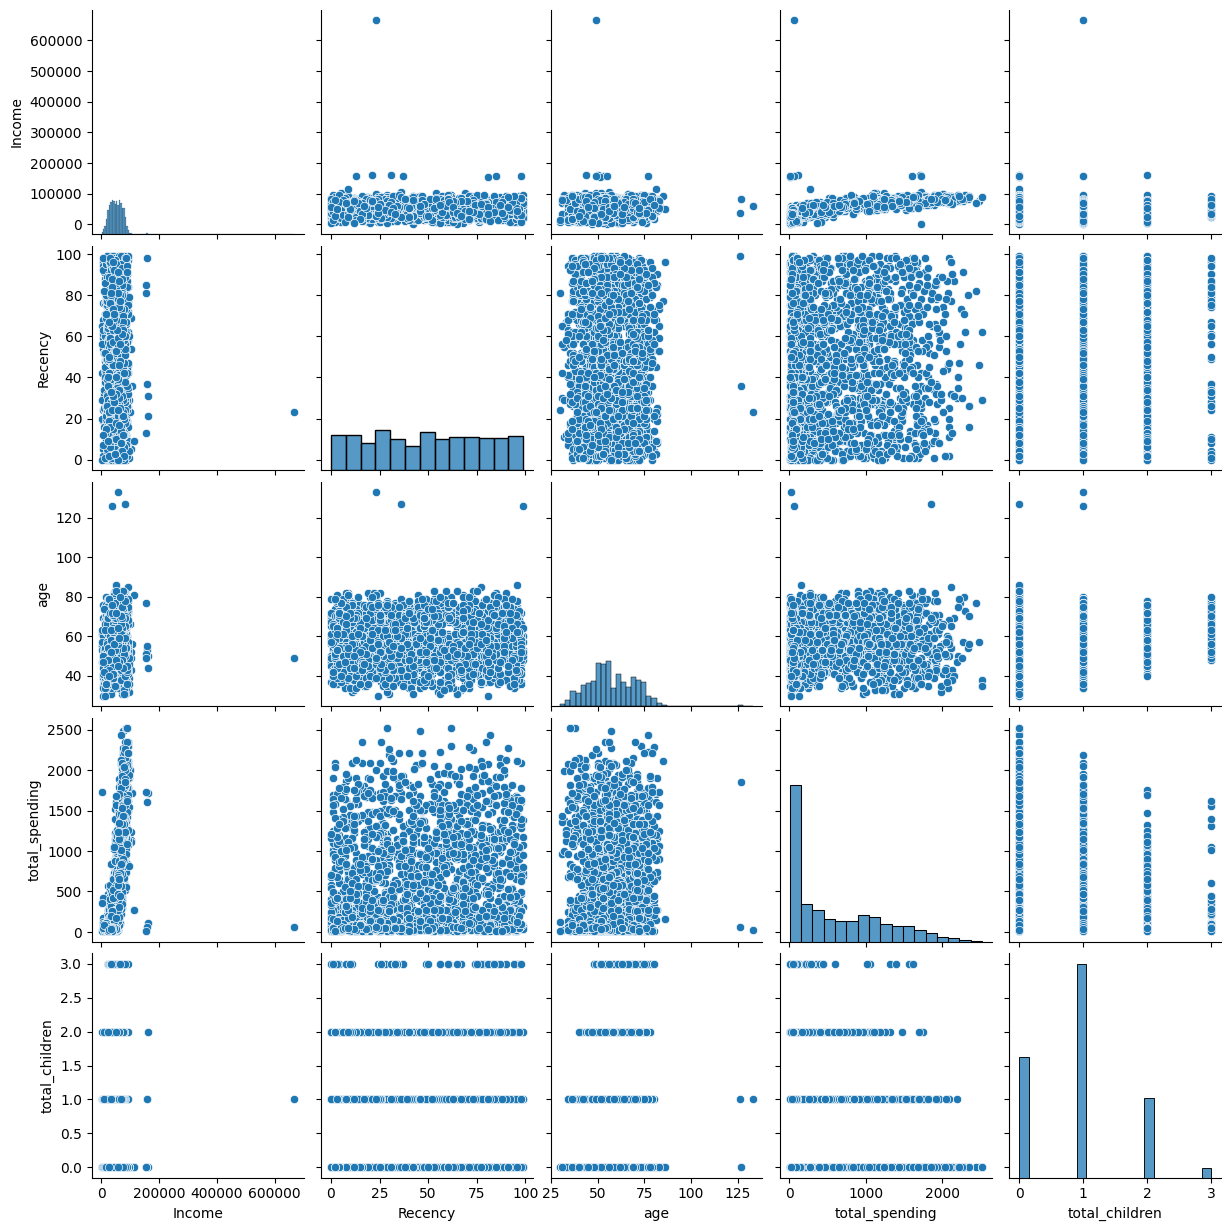

In [8]:
column = ["Income","Recency","age","total_spending","total_children"]
#relative plots
sns.pairplot(x[column])

In [9]:
print("data size with outlier:",len(encode))
encode = encode[(encode["age"]<90)]
encode = encode[(encode["Income"]<600000)]
print("data size without outlier:",len(encode))


data size with outlier: 2240
data size without outlier: 2236


# heatmap

In [10]:
correlation = encode.corr(numeric_only = True)

<Axes: >

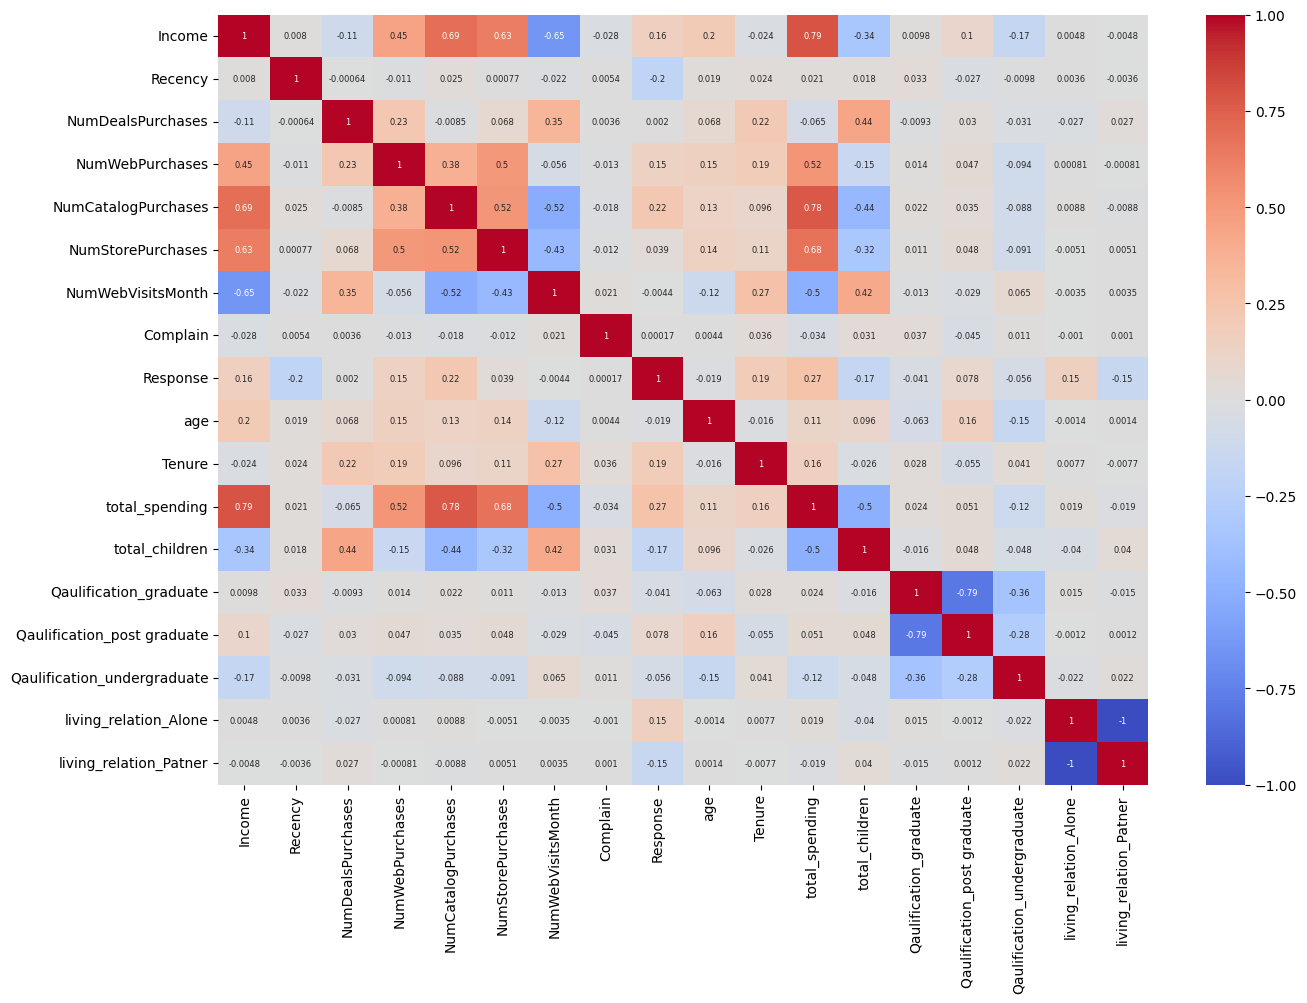

In [11]:
plt.figure(figsize =(15,10))
sns.heatmap(
    correlation,annot=True,annot_kws={"size":6},cmap="coolwarm"
)

In [12]:
scaled = StandardScaler()
encode_scaled = scaled.fit_transform(encode)

In [13]:
pca = PCA(n_components=3)
pca_dimension = pca.fit_transform(encode_scaled)

<Axes: >

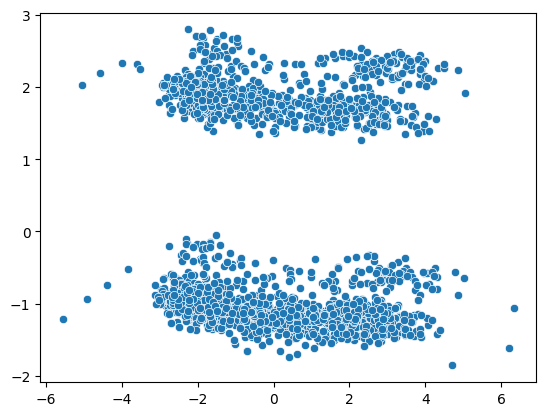

In [14]:
sns.scatterplot(x=pca_dimension[:,0],y=pca_dimension[:,1])

Text(0.5, 0.92, '3d projection')

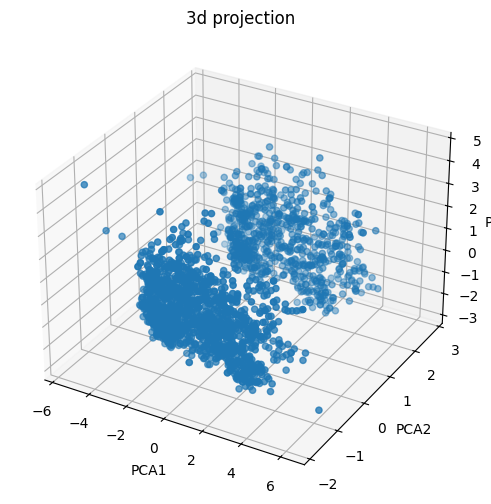

In [15]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111,projection="3d")
ax.scatter(pca_dimension[:,0],pca_dimension[:,1],pca_dimension[:,2])
ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d projection")


# anlyzing k
 # 1. elbow method

In [16]:
wcss =[]
for k in range(1,11):
  kmeans_model = KMeans(n_clusters = k,random_state = 42)
  kmeans_model.fit_predict(pca_dimension)
  wcss.append(kmeans_model.inertia_)  

In [17]:
knee = KneeLocator(range(1,11),wcss,curve ="convex",direction = "decreasing")
optimal_k = knee.elbow

In [18]:
print("best k= ",optimal_k)

best k=  4


Text(0, 0.5, 'wcss')

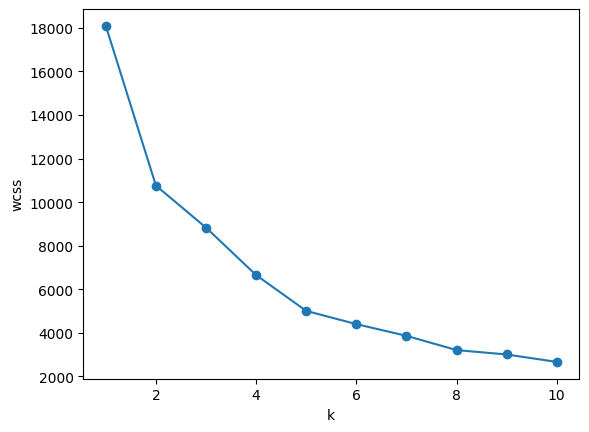

In [19]:
plt.plot(range(1,11),wcss,marker ="o")
plt.xlabel("k")
plt.ylabel("wcss")

# 2. silhouette score

In [20]:
scores =[]
for k in range(2,11):
    kmeans_model = KMeans(n_clusters = k,random_state = 42)
    labels = kmeans_model.fit_predict(pca_dimension)
    score = silhouette_score(pca_dimension,labels)
    scores.append(score)

Text(0, 0.5, 'silhouette_score')

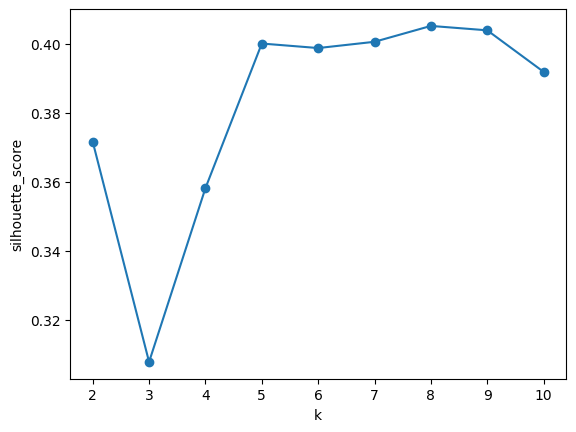

In [21]:
#plot
plt.plot(range(2,11),scores,marker="o")
plt.xlabel("k")
plt.ylabel("silhouette_score")


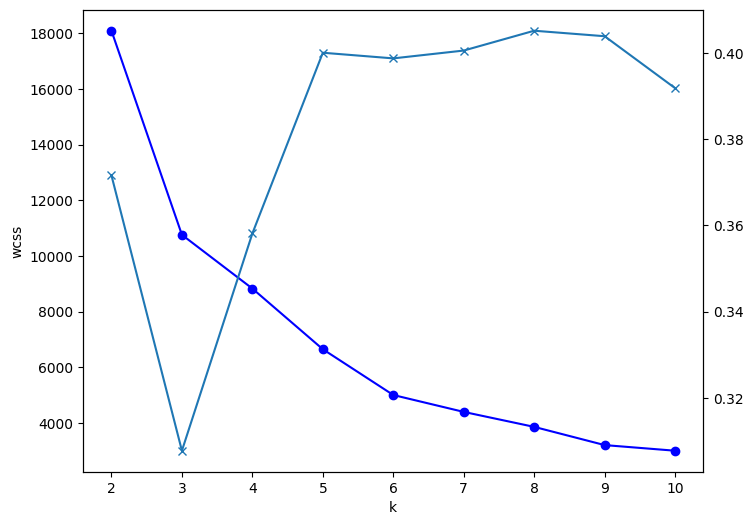

In [22]:
#combine plot
k_range = range(2,11)
fig,ax1 = plt.subplots(figsize=(8,6))
ax1.plot(k_range,wcss[:len(k_range)],marker="o",color ="blue")
ax1.set_xlabel("k")
ax1.set_ylabel("wcss")
ax2 =ax1.twinx()
ax2.plot(k_range,scores[:len(k_range)],marker="x")


In [23]:
kmeans_model = KMeans(n_clusters = 4,random_state = 42)
labels_kmeans = kmeans_model.fit_predict(pca_dimension)

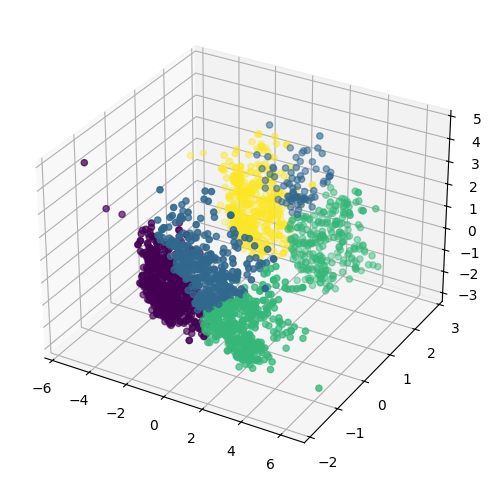

In [24]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111,projection="3d")
ax.scatter(pca_dimension[:,0],pca_dimension[:,1],pca_dimension[:,2],c =labels_kmeans)

In [25]:
agg_clf = AgglomerativeClustering(n_clusters =4,linkage ="ward")
labels_agg = agg_clf.fit_predict(pca_dimension)

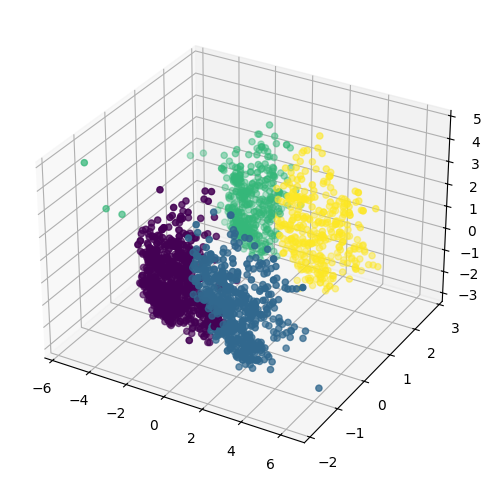

In [26]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111,projection="3d")
ax.scatter(pca_dimension[:,0],pca_dimension[:,1],pca_dimension[:,2],c =labels_agg)

In [27]:
encode["cluster"]=labels_agg


<Axes: xlabel='cluster', ylabel='count'>

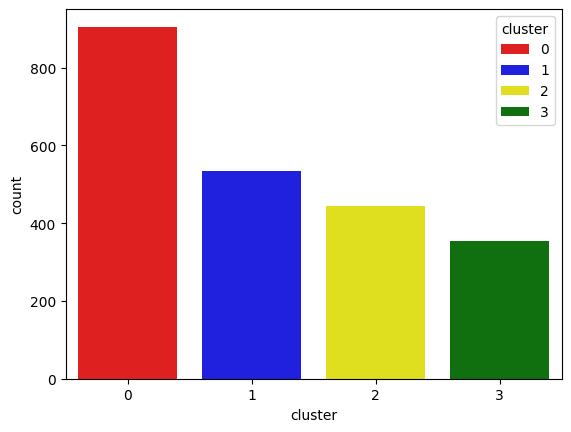

In [28]:
pal = ["red","blue","yellow","green"]
sns.countplot(x=encode["cluster"],palette = pal,hue = encode["cluster"])

<Axes: xlabel='total_spending', ylabel='Income'>

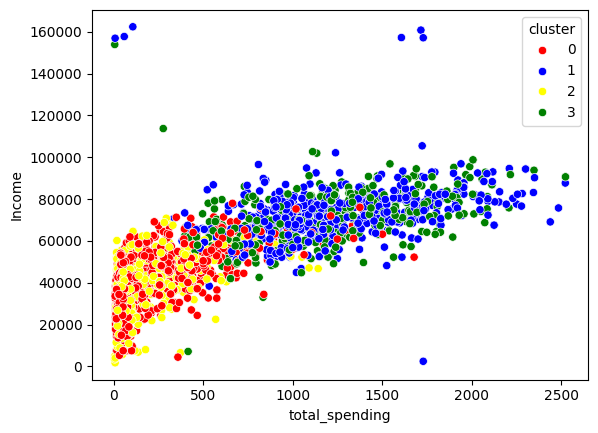

In [29]:
sns.scatterplot(x=encode["total_spending"],y= encode["Income"],hue = encode["cluster"],palette=pal)

In [30]:
cluster_summary = encode.groupby("cluster").mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        39690.146424  48.914917           2.594475         3.153591   
1        72814.930722  49.202247           1.958801         5.687266   
2        36973.792251  48.319820           2.594595         2.713964   
3        70730.038963  50.504249           1.855524         5.790368   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   0.969061           4.143646           6.307182  0.011050   
1                   5.498127           8.659176           3.580524  0.005618   
2                   0.837838           3.623874           6.659910  0.011261   
3                   5.014164           8.430595           3.728045  0.005666   

         Response        age      Tenure  total_spending  total_children  \
cluster   

# appling the model

In [31]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

scores = []
k_values = range(2,11)

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(pca_dimension)
    score = silhouette_score(pca_dimension, labels)
    scores.append(score)

for k, s in zip(k_values, scores):
    print(f"K = {k}, Silhouette = {s}")

K = 2, Silhouette = 0.37156531690748373
K = 3, Silhouette = 0.30775183737944595
K = 4, Silhouette = 0.35810628813323825
K = 5, Silhouette = 0.4000022648125704
K = 6, Silhouette = 0.39869498699701517
K = 7, Silhouette = 0.4005087799366829
K = 8, Silhouette = 0.40510588927499025
K = 9, Silhouette = 0.40383115274875814
K = 10, Silhouette = 0.39179413771645605


In [32]:
from sklearn.metrics import davies_bouldin_score

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(pca_dimension)
    db = davies_bouldin_score(pca_dimension, labels)
    print(f"K = {k}, DB Score = {db}")

K = 2, DB Score = 1.1551337971028914
K = 3, DB Score = 1.2764378179836509
K = 4, DB Score = 1.092558985002178
K = 5, DB Score = 0.9257574340686636
K = 6, DB Score = 0.8920376971176008
K = 7, DB Score = 0.8899081523453454
K = 8, DB Score = 0.9210001529036782
K = 9, DB Score = 0.8605641887147392
K = 10, DB Score = 0.8684207692595571


In [33]:
from sklearn.metrics import calinski_harabasz_score

for k in k_values:
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(pca_dimension)
    ch = calinski_harabasz_score(pca_dimension, labels)
    print(f"K = {k}, CH Score = {ch}")

K = 2, CH Score = 1522.1826374070179
K = 3, CH Score = 1171.1823111913009
K = 4, CH Score = 1279.978136147742
K = 5, CH Score = 1457.9646683870255
K = 6, CH Score = 1388.4004350160483
K = 7, CH Score = 1369.3158764152558
K = 8, CH Score = 1477.351085909716
K = 9, CH Score = 1397.764464915249
K = 10, CH Score = 1432.9211341855478
